# Advanced topics in functions, methods

In this chapter, we will discuss some more advanced topics used in Python for functions and/or methods.

We will begin by describing the concept of anonymous functions. Then, we will have an introduction to function decorators. Finally, we will discuss the concept of generator functions.

# `lambda` function

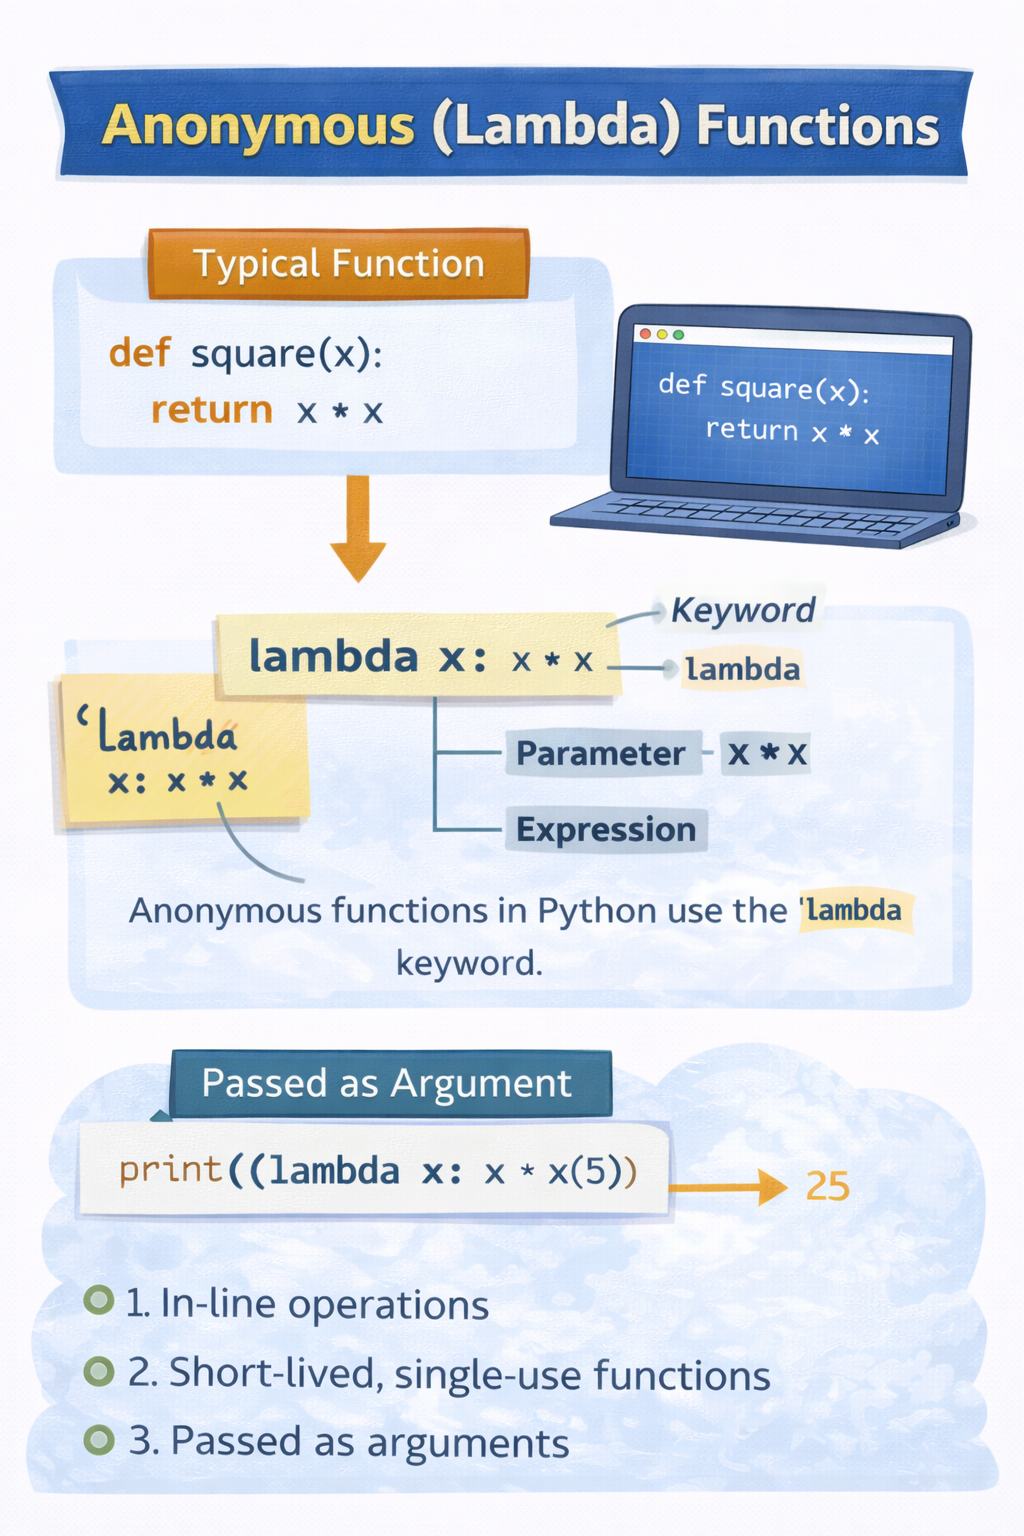

Sometimes, we need to define a function without a name (anonymous function).

We use `lambda` keyword for this.
- Also known as **one line functions**.

Can accept any number of arguments.

Defined as:
```python
lambda argument(s): expression
```

Has only a single expression.

Generally used in situations requiring a function for a short time period.
- `lambda` functions are not permanently stored in memory.

Here is the difference in defining a regular Python function compared to a `lambda` function:
```python
#Normal python function
def f(x):
    return x**2

#Lambda function
lambda x: x**2
```

<b>Pros:</b>
- Efficient for simple logical operations that are easy to understand.
- Single use function, no need to define it permanently.

<b>Cons:</b>
- Can perform a single operation.
- Nested expressions not possible.

**Note:** We do not need an explicit **return** statement in `lambda` functions. The interpreter executes the function body and returns the result automatically.

They are useful in cases where Python functions are used as inputs to **higher-order** functions.

They can be used in either of the two ways:

 - Variable assignment:
```python
mul = lambda a, b: a*b
print(mul(2,3))
```
 - Wrapped inside other functions:
```python
def Wrap(n):
    return lambda a: a*n
mul = Wrap(3)
print(mul(2))
```

### Examples:

<b>Lists:</b>

* `filter(function, iterable)`
    - Used to return values fitting certain criteria.
    - `iterable` can be any sequence (e.g., a list in this case).
    - `function` is usually a `lambda` function.
    - Example:
```python
list_1 = [1,2,3,4,5,6,7,8,9]
list(filter(lambda x: x%2==0, list_1))
### Output
[2, 4, 6, 8]
```
* `map(function, iterable)`
    - Returns a list of the same length as the `iterable`, modified based on the `function`.
    - Example:
```python
list_1 = [1,2,3,4,5,6,7,8,9]
cubed = map(lambda x: pow(x,3), list_1)
list(cubed)
### Output
[1, 8, 27, 64, 125, 216, 343, 512, 729]
```

## <b><up>*</up>Use in `Pandas` dataframes</b>

Anonumous functions are very useful in creating new features to `pandas` dataframes.

Let's create a dataframe with some random family features:
```python
import pandas as pd
df = pd.DataFrame({
    'Name': ['Luke','Gina','Sam','Emma'],
    'Status': ['Father', 'Mother', 'Son', 'Daughter'],
    'Birthyear': [1976, 1984, 2013, 2016],
})
```

In [1]:
!pip install pandas
import pandas as pd
df = pd.DataFrame({
    'Name': ['Luke','Gina','Sam','Emma'],
    'Status': ['Father', 'Mother', 'Son', 'Daughter'],
    'Birthyear': [1976, 1984, 2013, 2016],
})
df

zsh:1: /Users/noahdonovan/python-programming-course/.venv/bin/pip: bad interpreter: /Users/noahdonovan/python-intro-course/.venv/bin/python3.14: no such file or directory


,Name,Status,Birthyear
0,Luke,Father,1976
1,Gina,Mother,1984
2,Sam,Son,2013
3,Emma,Daughter,2016


Feature `Birthyear` is not very helpful, we would be more interested in a person's age

Use `apply()` along with a `lambda` function to create a new feature `age`:
```python
df['age'] = df['Birthyear'].apply(lambda x: 2022-x)
```

If you want to get all ages for family members over 18 years old:
```python
list(filter(lambda x: x>18, df['age']))
```

Or maybe you want to modify the feature `age`:
```python
df['double age'] = df['age'].map(lambda x: x*2)
```

In [10]:
df['age'] = df['Birthyear'].apply(lambda x: 2023-x)
df

,Name,Status,Birthyear,age
0,Luke,Father,1976,47
1,Gina,Mother,1984,39
2,Sam,Son,2013,10
3,Emma,Daughter,2016,7


In [11]:
df['Over18'] = df['age'].apply(lambda x: 'True' if x > 18 else 'False')
df

,Name,Status,Birthyear,age,Over18
0,Luke,Father,1976,47,True
1,Gina,Mother,1984,39,True
2,Sam,Son,2013,10,False
3,Emma,Daughter,2016,7,False


In [12]:
print(list(filter(lambda x: x>18, df['age'])))

[47, 39]


In [13]:
df['double age'] = df['age'].map(lambda x: x*2)
df

,Name,Status,Birthyear,age,Over18,double age
0,Luke,Father,1976,47,True,94
1,Gina,Mother,1984,39,True,78
2,Sam,Son,2013,10,False,20
3,Emma,Daughter,2016,7,False,14


In [14]:
import pandas as pd

df = pd.read_csv('travel-times.csv')
df

FileNotFoundError: [Errno 2] No such file or directory: 'travel-times.csv'

In [15]:
df['AvgSpeed_cat'] = df['AvgSpeed'].apply(lambda x: 'Slow' if x < 60 else 'Fast')
df['AvgSpeed_cat']

KeyError: 'AvgSpeed'

----------------------------------------

# Function decorators

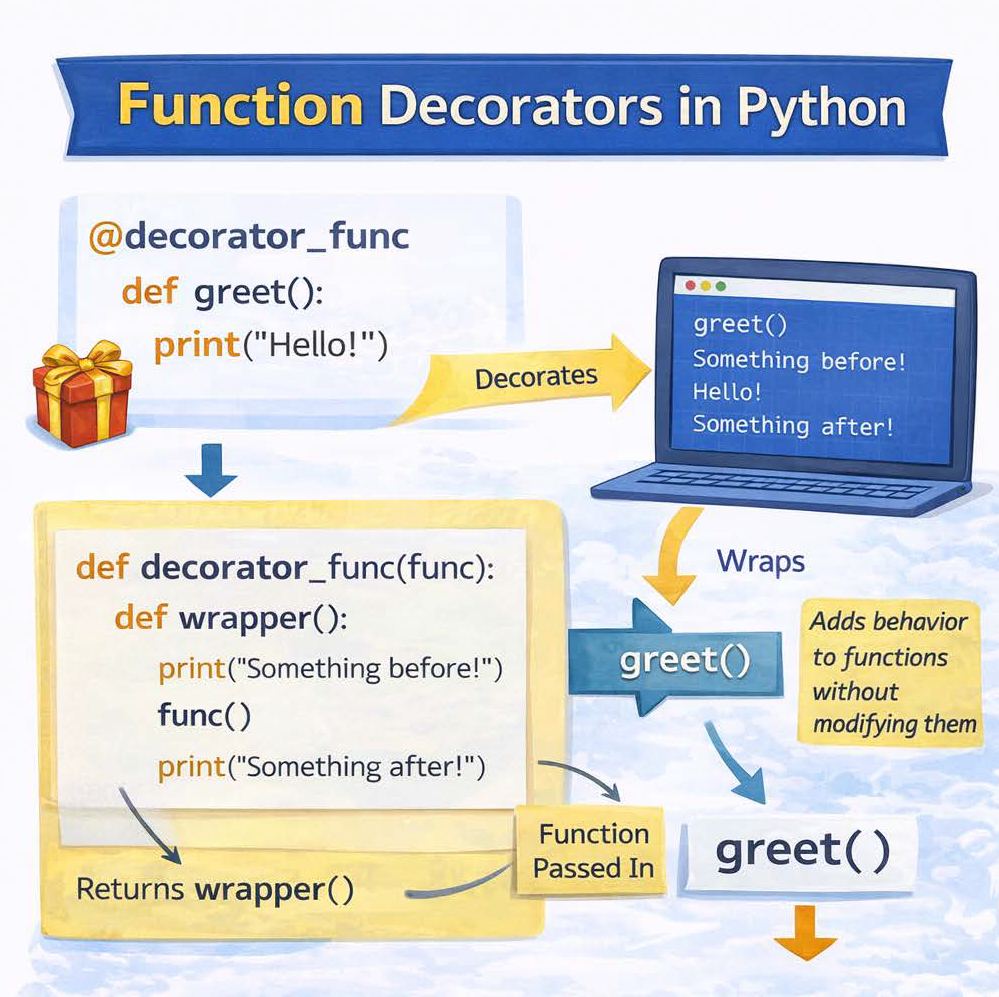

Decorators are extremely useful tools in Python.

A decorator is a function that takes another function as parameter and extends its functionality without explicitly modifying it.

It allows us to modify the behavior of a function or a class without touching its source code.
- In other words, a decorator wraps around a function in order to extend its behaviors, without permanently modifying it.

### First-class citizens

Let's revisit some information we discussed about earlier.

In Python, functions are first-class citizens:
- Functions can be assigned as regular variables.
```python
def say_hi(username):
     return 'Hi' + username
hi_name = say_hi
print(hi_name('Bruce Wayne'))
```
- Functions can be passed as arguments to other functions.
```python
def print_hello(user):
      print('Hello', user)
def hi_with_function(func, username):
      func(user_name)
hi_with_function(print_hello, 'Clark Kent')
```
- Functions can return functions.
```python
def return_hi_function():
      return say_hi
hi = return_hi_function()
print(hi('Spiderman'))
```
- Functions can have other functions (inner functions or nested functions) in their function body.
```python
def outer_func(msg):
  # define a nested function
     def inner_func():
        print(msg, 'from nested function')
     inner_func()
outer_func('The Batman')
```

A decorator takes in a function as an argument, adds some functionality to it and returns it back to the caller.

Some programmers call this action **metaprogramming** because a part of the program tries to modify another part of the program at compile time.

```python
def first_decorator(func):
  def wrapper():
    print('Before running {func.__name__} function')
    func()
    print('After running {func.__name__} function')
  return wrapper

def greet():
  print('Hello there')
# call first_decorator
greet = first_decorator(greet)
# call greet now
greet()
```

The example above defines a simple decorator function, `first_decorator()` that has a nested function (`wrapper()`) in it.

`first_decorator()` returns this `wrapper()` function.
- `wrapper()` prints some text then calls the function which is given as parameter; finally, it prints another text.

After defining the function that is to be decorated (`greet()`), we call `first_decorator` using `greet()` as input, and assign the result to the `greet` variable.

Calling now the `greet()` function, we see that its behavior is modified.
- In its original form, it prints one line.
- After decorating, it prints three.

### Decorator syntax

The above example, while correct, is not very readable. Python provides a better and more readable syntax for decorators by putting the notation `@decorator-name` over the function that we want to modify.

```python
def echo(fnc):
    def wrapper():
        fnc()
        fnc()
    return wrapper

@echo
def print_hello():
    print('Hello!')
```

The decorator `echo` returns local function `wrapper` that calls argument `fnc` twice (hence, the *echo*)

### Decorators with Parameters

So far we saw how a decorator is defined. Let's see now what happens if the function which we want to decorate accepts parameters.

Let's assume we want to define a function which takes two numbers, performs division, and returns the result:

```python
def division(x, y):
  return x/y

res_1 = division(20, 5)
res_2 = division(8,0)
```

`res_2` obviously has an issue since we can't divide by zero.
- We can amend it by adding a `try-except` block, but let's assume we don't want to change the function. So we need another way.

**Solution:** decorate the function with a proper decorator that will be responsible of checking if the second parameter is zero or not.

```python
def division_decorator(f):
  def wrapper(a, b):
    if b == 0:
      print('Division by zero not allowed!')
      return
    else:
      return f(a, b)
    return wrapper

@division_decorator
def division(x, y):
  return x/y
```

**Decorator example: Addition function**

Suppose you have a simple function called `add_func`, that takes as input arguments two integers and returns their summation.

```python
def add_func(a, b):
    return a + b
```

Obviously, this function is very limited in what it can do. It'd be better if you could reinforce it to be able to take more complex arguments and add them.

For example, `add_func` could take as input a list of tuples and return the sum of all elements in them.

That can be achieved using a *decorator*:
- Create a decorator and name it `add_list`
    * Function that takes another function as its argument
- Inside the decoratored function, define a local function called `inner`.
    * `inner` function takes a list of tuples as its argument.
    * Loops through this list and applies `add_func` on each tuple
    * Returns a list of these values summed up.
- `add_list` finally returns the inner function.

In [ ]:
def add_list(fnc):
    def inner(list_of_tuples):
        return [fnc(list_of_tuples[0][i], list_of_tuples[1][i]) for i in range(len(list_of_tuples[0]))]
    return inner

@add_list
def add_func(a, b):
    return a + b

add_func([(1,2,3),(4,5,6)])

[5, 7, 9]

```python
def add_list(fnc):
    def inner(list_of_tuples):
        return [fnc(list_of_tuples[0][i], list_of_tuples[1][i]) for i in range(len(list_of_tuples[0]))]
    return inner
```

```python
@add_list
def add_func(a, b):
    return a + b
```

```python
print(add_func([(1,3), (3, 5)]))
```

### General decorators

In the example of the `division_decorator`, we saw that the parameters of the `division()` function and the `wrapper()` function inside the decorator **must match**.

That is because the `wrapper()` function will replace the `division()` function after decoration; therefore, their parameters should match.

Here lies a potential problem: What if we want to use the same decorator with multiple functions? What if these functions have different numbers of parameters?

**Answer:**

Let's revisit the `echo` example, with some modifications:

```python
def echo(fnc):
    def wrapper(*args, **kwargs):
        fnc(*args, **kwargs)
        fnc(*args, **kwargs)
    return wrapper

@echo
def print_hello():
    print('Hello!')

@echo
def print_num(a):
  print(a)  
    
print_num(2)
print_hello()
```

Decorator `echo` is now a general decorator. That is because the `wrapper` function has the `*args, **kwargs` arguments.
- The asterisk `*` notation is called `wildcard`.

**Note:** We use the `*` notation like this - `*args` OR `**kwargs` - as a function's argument when we have doubts about the number of  arguments we should pass in a function.

Those parameters enable the `wrapper` function to take any number of parameters, and as a result, decorate multiple functions.



In [ ]:
def echo(fnc):
    def wrapper(*args, **kwargs):
        fnc(*args, **kwargs)
        fnc(*args, **kwargs)
    return wrapper

@echo
def print_hello():
    print('Hello!')

@echo
def print_num(a):
  print(a)

@echo
def print_sum(a,b):
  print(a+b)

@echo
def print_sum_int(a,b,c=5):
  print(a+b+c)

print_num(2)
print_hello()
print_sum('2','3')
print_sum_int(1,2,3)

2
2
Hello!
Hello!
23
23
6
6


**Comments on decorators:**

Remember that the base syntax of function decoration is: `func = func_decorator(func)`, and that `func_decorator` returns a nested function (the `wrapper` we saw above).

Hence, the function `func` essentially is `wrapper` now, not the old `func`.

### Decorator arguments

Decorators can also take inputs.

Going back to the `add_func` example, suppose we want to further extend it to return squared values.

This can be done with the following steps:
- Pass an integer to the decorator function to use as the exponent after the two values in the tuple have been added together.
- Simply define a new decorator over the current one.

```python
def meta_decorator(power):
    def add_list(fnc):
      def inner(list_of_tuples):
        return [fnc(list_of_tuples[0][i], list_of_tuples[1][i]) ** power for i in range(len(list_of_tuples[0]))]
      return inner
    return add_list


@meta_decorator(2)
def add_func(a, b):
    return a + b


print(add_func([(1,3), (3, 5)]))
```

You can change the `meta_decorator` argument to return any power you want, not just squared values.

In [ ]:
def meta_decorator(power=1):
    def add_list(fnc):
      def inner(list_of_tuples):
          return [fnc(list_of_tuples[0][i], list_of_tuples[1][i]) ** power for i in range(len(list_of_tuples[0]))]
      return inner
    return add_list


@meta_decorator(3)
def add_func(a, b):
    return a + b


print(add_func([(1,3), (3, 5)]))

[64, 512]


Going back to the `echo` example, what if we want to specify how many times function `print_hello` is called?

To do that, create another decorator function that wraps around the original one:

```python
def outer_decorator(count=1):
    print(f'Inside outer decorator; Number of echos: {count}')
    def inner_decorator(fnc):
        print(f'Inside inner decorator')
        def wrapper():
            print(f'Inside wrapper')
            for _ in range(count):
                fnc()
        return wrapper
    return inner_decorator

@outer_decorator(3)
def print_hello():
    print('Hello')
```


In [7]:
def outer_decorator(count=1):
    print(f'Inside outer decorator; Number of echos: {count}')
    def inner_decorator(fnc):
        print(f'Inside inner decorator')
        def wrapper():
            print(f'Inside wrapper')
            for _ in range(count):
                fnc()
        return wrapper
    return inner_decorator

@outer_decorator(3)
def print_hello():
    print('Hello')

Inside outer decorator; Number of echos: 3
Inside inner decorator


In [8]:
print_hello()

Inside wrapper
Hello
Hello
Hello


Even before calling `print_hello`, the decorators were "initialized"
- Messages were printed on the screen in advance
- Only after calling `print_hello` the message inside `wrapper` is shown

The process above follows the steps below:

`@outer_decorator(count=3) -> @inner_decorator -> decoration`

Another way of looking at those steps is through Python itself:

```python
def print_hello():
    print('Hello')
    
inner_decorator = outer_decorator(count=3)
wrapper = inner_decorator(print_hello)
wrapper()
```

### <up>**</up>Decorators with default arguments

When a decorator takes arguments, it has to be called using brackets:
`@decorator()`.

Obviously, it is important to avoid errors that migh arise from forgetting to put brackets, or if the decorator takes default arguments.
- Decorators are functions, they can have default arguments as well

To handle such situations, we include a mechanism to take care of potential issues.
- That way, `@decorator` and `@decorator()` will both be acceptable.
    * In `@decorator` case, the decorator function takes the to-be-decorated function as a positional argument,
    * In `@decorator()`, the decorator function executes and returns its nested decorator function, which subsequently decorates the to-be-decorated function.
    * Create two separate branches, one for each case.

```python
def outer_decorator(fnc=None, count=1):
    print(f'Inside outer decorator; Number of echos: {count}')
    # Branch one, @outer_decorator with brackets
    if func in None:
        print('func is None')
        def inner_decorator(fnc):
            print(f'Inside inner decorator')
            def wrapper():
                print(f'Inside wrapper')
                for _ in range(count):
                    fnc()
            return wrapper
        return inner_decorator
    
    # Branch two, @outer_decorator without brackets
    def wrapper():
        print(f'Inside the other decorator')
        for _ in range(count):
            fnc()
    return wrapper()

@outer_decorator
def print_hello():
    print('Hello, no decorator args')
    
@outer_decorator(count=2)
def print_hello():
    print('Hello, with decorator args')
```

In [9]:
def outer_decorator(fnc=None, count=1):
    print(f'Inside outer decorator; Number of echos: {count}')
    # Branch one, @outer_decorator with brackets
    if fnc is None:
        print('fnc is None')
        def decorator(fnc):
            print(f'Inside inner decorator')
            def wrapper():
                print(f'Inside wrapper')
                for _ in range(count):
                    fnc()
            return wrapper
        return decorator

    # Branch two, @outer_decorator without brackets
    def wrapper():
        print(f'Inside the other wrapper')
        for _ in range(count):
            fnc()
    return wrapper

In [10]:
@outer_decorator
def print_hello():
    print('Hello, no decorator args')

Inside outer decorator; Number of echos: 1


In [11]:
print_hello()

Inside the other wrapper
Hello, no decorator args


In [ ]:
@outer_decorator(count=2)
def print_hello():
    print('Hello, with decorator args')

In [ ]:
print_hello()

### Useful decorator functions

Creating custom-made decorators can be proved to be useful in many occasions.

However, many Python modules come with built-in decorators that provide significant benefits.

Here is a (non-exhaustive) list of popular decorator functions:
- `@lru_cache`
    * Implemented with the `functools` module
    * Used to speed up consecutive runs of functions and operations using cache memory

In [ ]:
def factorial(n):
    return n * factorial(n-1) if n else 1

%timeit factorial(10)

1.79 µs ± 551 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


In [ ]:
from functools import lru_cache

@lru_cache
def factorial(n):
    return n * factorial(n-1) if n else 1

%timeit factorial(10)

115 ns ± 41.9 ns per loop (mean ± std. dev. of 7 runs, 10000000 loops each)


- `@jit`
    * Just-in-Time calculation provided by the `numba` module
    * Running code in Python begins with compilations that produces overhead, due to memory allocation and type assignment to variables, functions, etc.
    * `@jit` decorator does that during execution

In [ ]:
from numba import jit
import random

@jit(nopython=True)
def monte_carlo_pi(nsamples):
    acc = 0
    for i in range(nsamples):
        x = random.random()
        y = random.random()
        if (x ** 2 + y ** 2) < 1.0:
            acc += 1
    return 4.0 * acc / nsamples

%timeit monte_carlo_pi(100000)

## Class method decorators

Python provides special decorator types used on class methods.

Let's see some of them.

### `@property` method: Define Pythonic getters and setters

The `@property` decorator is a built-in decorator in Python.

We can use the `@property` to decorate any method in a class that we want to use the method as a *getter*.

The following three decorators define a property:
- `@property`: Declares the method as a property.
  * This is equivalent to the *getter* methods we discussed before. Decorating a class method with `@property` the method becomes a getter.
- `@<property-name>.setter`: Specifies the setter method for a property that sets the value to a property.
- `@<property-name>.deleter`: Specifies the delete method as a property that deletes a property.

The benefit of using the `@property` decorator instead of the more conventional `get_somename()`, `set_somename()`, `del_somename()` is that we can use the same name for all of them. In that case, the `@property`, `@property.setter` and `@property.deleter` will resolve which one is used at anytime.


**Example:**

In the following, we declare method `name` as a property; the method returns the value of that property.

`@property` decorator applied to the `name()` method.

The `name()` method returns the private instance attribute value `self.__name`:

In [ ]:
class Student:
    def __init__(self, name):
        self.__name = name

    @property
    def name(self):
        return self.__name

We can now use the `name()` method as a property to get the value of the `__name` attribute:

In [ ]:
s = Student('Steve')
s.name

'Steve'

To modify the property `name` value, we must define the setter method for the name property using `@name.setter` decorator:

In [ ]:
class Student:
    def __init__(self, name):
        self.__name=name

    @property
    def name(self):
        return self.__name

    @name.setter   #property-name.setter decorator
    def name(self, value):
        self.__name = value

s = Student('Steve')
print(s.name)
s.name = 'Bill'
print(s.name)

Steve
Bill


If necessary, we can also use the `@name.deleter` decorator to define the method that deletes a property.

The deleter would be invoked when you delete the property using keyword `del`.

Once the property is deleted, it cannot be accessed again using the same instance.

In [ ]:
class Student:
    def __init__(self, name):
        self.__name = name

    @property
    def name(self):
        return self.__name

    @name.setter
    def name(self, value):
        self.__name=value

    @name.deleter   #property-name.deleter decorator
    def name(self, value):
        print('Deleting..')
        del self.__name

**Comment:**

Make note that the property name on `@<property_name>.setter` and `@<property_name>.deleter` will be based on the name of the method that is decorated with the `@property` decorator.

### `@classmethod`

Used to declare a method in the class as a class method that can be called using `ClassName.MethodName()`.

The class method can also be called using an object of the class.

`@classmethod` characteristics:
- Declares a class method.
- The first parameter must be `cls`, which can be used to access class attributes.
- The class method can only access the class attributes but not the instance attributes.
- The class method can be called using `ClassName.MethodName()` and also using object.
- It can return an object of the class.

In [ ]:
class Student:
    name = 'unknown' # class attribute
    def __init__(self):
        self.age = 20  # instance attribute

    @classmethod
    def tostring(cls):
        print('Student Class Attributes: name=',cls.name)

Student class contains a class attribute name and an instance attribute age.

The `tostring()` method is decorated with the `@classmethod` decorator that makes it a class method, which can be called using the `Student.tostring()`.

The first parameter of any class method must be `cls` that can be used to access the class's attributes.

*You can give any name to the first parameter instead of `cls`.*

In [ ]:
Student.tostring()

Student Class Attributes: name= unknown


The same method can be called using an object:

In [ ]:
std = Student()
std.tostring()

Student().tostring()

Student Class Attributes: name= unknown
Student Class Attributes: name= unknown


The class method can only access class attributes, but not the instance attributes.

It will raise an error if trying to access the instance attribute in the class method.

In [ ]:
class Student:
    name = 'unknown' # class attribute
    def __init__(self):
        self.age = 20  # instance attribute

    @classmethod
    def tostring(cls):
        print('Student Class Attributes: name=',cls.name,', age=', self.age)

Student.tostring()

NameError: ignored

The class method can also be used as a factory method to get an object of the class

In [ ]:
class Student:
    def __init__(self, name, age):
        self.name = name  # instance attribute
        self.age = age # instance attribute

    @classmethod
    def getobject(cls):
        return cls('Steve', 25)

In [ ]:
std = Student.getobject()
print(std.name)
print(std.age)

Steve
25


### `@staticmethod`

Built-in decorator that defines a static method in the class in Python.

A static method doesn't receive any reference argument whether it is called by an instance of a class or by the class itself.

`@staticmethod` characteristics:
- Declares a static method in the class.
- It cannot have `cls` or self parameter.
- The static method cannot access the class attributes or the instance attributes.
- The static method can be called using `ClassName.MethodName()` and also using `object.MethodName()`.
- It can return an object of the class.


In [ ]:
class Student:
    name = 'unknown' # class attribute

    def __init__(self):
        self.age = 20  # instance attribute

    @staticmethod
    def tostring():
        print('Student Class')

Student class declares the `tostring()` method as a static method using the `@staticmethod` decorator.

Note that it cannot have `self` or `cls` parameter.

The static method can be called using the `ClassName.MethodName()` or `object.MethodName()`

In [ ]:
print(Student.tostring())
print(Student().tostring())
std = Student()
print(std.tostring())

Student Class
None
Student Class
None
Student Class
None


The static method cannot access the class attributes or instance attributes.

It will raise an error if try to do so.

In [ ]:
class Student:
    name = 'unknown' # class attribute

    def __init__(self):
        self.age = 20  # instance attribute

    @staticmethod
    def tostring():
        print('name=',cls.name,'age=',self.age)

The following will be the output when you call the above static method.

In [ ]:
Student.tostring()

NameError: ignored

----------------------------------------

# Generator functions

Python provides **generators** to help us easily create iterators (objects that can be used to iterate over).

*A generator allows us to declare a function that behaves like an iterator, i.e., it can be used in a `for-loop`.*

More simply, a generator is a function that returns an iterator object.

### Defining generators

This type of function does not return a single value; instead, it returns an iterator **object**.

This object is a *lazy iterator* with a sequence of values.
- Objects that loop over like a list.
- Helpful for reducing heavy memory loads in intense computations.



In a generator function, a `yield` statement is used rather than a `return` statement.

```python
def mygenerator(index):
    yield index + 1
```

Requires an iterator to work, coupled with keyword `next`

In [ ]:
def mygenerator(index):
    print("This yields the first number")
    yield index + 1
    print("This yields another number")
    yield index + 2

gen = mygenerator(0)
next(gen)

This yields the first number


1

In [ ]:
next(gen)

This yields another number


2

The generator function does not include the `return` keyword.

Including `return` will terminate the function.

Difference between `yield` and `return`:
 - `yield` returns a value and pauses the execution *at that point* while maintaining the internal states.
 - `return` returns a value and terminates the execution of the function.

When using `yield`, the state of the function is **remembered**.
- when `next()` is called, the previously yielded variable `num` is incremented, and then yielded again.

### Generate infinite sequences

Normally, you use `range()` to generate a sequene of numbers:

```python
a = range(5)
print(list(a))
```

In [ ]:
a = range(5)
print(list(a))

However, using `range()` to produce an infinite sequence is not doable due to memory constraints.

A generator function can be used instead:

```python
def infinite_sequence():
    num = 0
    while True:
        yield num
        num += 1
```

In [ ]:
def infinite_sequence():
    num = 0
    while True:
        yield num
        num += 1

for i in infinite_sequence():
    print(i, end=" ")

Instead of a `for loop`, use `next` for a more controllable output:

In [ ]:
gen = infinite_sequence()
next(gen)

In [ ]:
next(gen)

### <up>**</up>Detecting Palindromes

You can use generator functions to create a **palindrome detector**.

*This is one of the most popular Python coding interview questions!!*

Palindromes are sequences of numbers and letters that they read the same regardless if you read them forwards or backwards

A palindrome detector can be designed as:

```python
def is_palindrome(num):
    # Skip single-digit inputs
    if num // 10 == 0:
        return False
    temp = num
    reversed_num = 0

    while temp != 0:
        reversed_num = (reversed_num * 10) + (temp % 10)
        temp = temp // 10

    if num == reversed_num:
        return num
    else:
        return False
```

In [ ]:
def is_palindrome(num):
    # Skip single-digit inputs
    if num // 10 == 0:
        return False
    temp = num
    reversed_num = 0

    while temp != 0:
        reversed_num = (reversed_num * 10) + (temp % 10)
        temp = temp // 10

    if num == reversed_num:
        return True
    else:
        return False

for i in infinite_sequence():
    if is_palindrome(i):
        print(i)

Generator expressions can be used to create generators in a few lines of code, similar to list comprehensions.

However, you are able to create and use them without building and holding the entire object in memory, unlike list comprehensions.

```python
squared_list = [num**2 for num in range(10000)]
squared_gen = (num**2 for num in range(10000))
```

In [ ]:
squared_list = [num**2 for num in range(10000)]
squared_gen = (num**2 for num in range(10000))

In [ ]:
type(squared_list)

list

In [ ]:
type(squared_gen)

generator

So, how can we tell the difference between the two?

**Profiling:** A process where we can see the amount of memory allocated in both cases

In [ ]:
import sys

sys.getsizeof(squared_list) # in bytes

87616

In [ ]:
sys.getsizeof(squared_gen)

112

### <up>**</up> Advanced generator methods

Except `yield`, generator functions can also make use of these methods:
- `.send()`
    * Sends a value back to the generator
- `.throw()`
    * Handles exception
- `.close()`
    * Stops generator after a given amount of digits

#### `.send()` method

Going back to the palindrome detector, this time we will use `.send()` to send a new value back to the generator every time we find a palindrome.



In [8]:
def infinite_palindromes():
    num = 0
    while True:
        if is_palindrome(num):
            i = (yield num)
            if i is not None:
                num = i
        num += 1

`i = (yield num)` is a special expression to use for assigning the yielded value to an object
- allows manipulation of yielded value
- allows sending back a value to the generator

In [7]:
pal_gen = infinite_palindromes()
for i in pal_gen:
    digits = len(str(i))
    pal_gen.send(10 ** (digits))

NameError: name 'is_palindrome' is not defined

Focus on the idea of *sending back* a value.
- This is what's called a **coroutine**, a generator function in which data can be passed to.
- Useful for constructing data pipelines.

#### `.throw()` method

Allows throwing exceptions with the generator.

Assume that in the previous example, we want to avoid palindromes that are larger than 5 digits in length

In [4]:
pal_gen = infinite_palindromes()
for i in pal_gen:
    print(i)
    digits = len(str(i))
    if digits == 5:
        pal_gen.throw(ValueError("Palindrome larger than 5 digits in length"))
    pal_gen.send(10 ** (digits))

NameError: name 'infinite_palindromes' is not defined

#### `.close()` method

Stops a generator

We can modify the previous example so instead of throwing an exception, we can instead simply stop the generator execution.

In [3]:
pal_gen = infinite_palindromes()
for i in pal_gen:
    print(i)
    digits = len(str(i))
    if digits == 5:
        pal_gen.close()
    pal_gen.send(10 ** (digits))

NameError: name 'infinite_palindromes' is not defined

### Data pipelines with generators

Using the Techcrunch Continental USA set that describes funding rounds and dollar amounts for various startups based in the USA, we will analyze this file to get the total and average of all series A rounds in the dataset.

Steps to follow:
1. Read every line on the file
2. Split into specific fields of value
3. Extract column names
4. Create dictionary using column names and values
5. Filter irrelevant rounds
6. Calculate total and average round values

In [2]:
"""Step 1: Read the file using a generator function"""
file_name = "techcrunch.csv"
lines = (line for line in open(file_name))

FileNotFoundError: [Errno 2] No such file or directory: 'techcrunch.csv'

In [ ]:
"""Step 2: Split each line into values by commas, using another generator"""
list_line = (s.rstrip().split(",") for s in lines) # generator that splits each line to distinct values

In [ ]:
"""Step 3: Extract column names using next(); column names is the first line on the file"""
cols = next(list_line)

In [ ]:
"""Step 4: Create dictionaries with column names being the keys
and unites them with a zip() call."""
company_dicts = (dict(zip(cols, data)) for data in list_line)

In [ ]:
"""Step 5: Use another generator to filter through and takes raised amount
for those where round key is 'a'"""
funding = (
    int(company_dict["raisedAmt"])
    for company_dict in company_dicts
    if company_dict["round"] == "a"
)

So far, no iteration has been conducted, only created the generators.

Iterations are either using a `for loop`, a function that uses looping, or a function like `sum()`, which works on iterables

In [ ]:
"""Step 6: Perform calculations summing up over all iterators"""
total_series_a = sum(funding)
print(f"Total series A fundraising: ${total_series_a}")

In [ ]:
def avg(grades):
  assert len(grades) != 0, 'no data'
  return sum(grades) / len(grades)

avg([])

In [ ]:
def avg2(grades):
  if len(grades) == 0:
    raise AssertionError('list has no data')
  return sum(grades) / len(grades)

avg2([])

### Benefits of generators

Generators are great tools, especially when we need to deal with large data in relatively limited memory.

**Memory efficiency:**

Using a normal function to return a very large sequence is not advisable, it might lead to memory overflow.

However, using a generator, the function will return the items one by one, without the need to wait for all of the items in the list to be executed by the function.

**Lazy evaluation:**

Lazy evaluation is computing a value when it is really needed, not when instantiated.

Allows us to start using the data immediately while the whole dataset is still being computed.

**Implement and Readability:**

Using only the `yield` keyword, special methods `__iter__()` and `__next__()` are called under the hood without us needing to worry about it.

**Dealing with Infinite Streams:**

We already saw an example of creating an infinite list of numbers. In theory, we cannot store an infinite stream in memory, as well as we cannot be sure about how much size we will need to store it. A generator produces only one item at a time, representing an infinite stream of data (without having to store all of it in memory).